# GAMING - Navigare tra migliaia di titoli

### La SoftAlex è una software house creata questo stesso anno a Casale Litta, Italia. 

Esce vittoriosa dal lancio del suo primo gioco sul mercato. Contro ogni aspettativa, centinatia di migliaia di persone hanno comprato "Tartis". Si tratta di un azzeccatissimo mix tra sport e sparatutto dove alieni invasori giocano a tennis fino all'ultimo sangue contro i protettori della terra. 

Il gioco è stato prodotto con 50€ in un garage, come nella più sognante delle storie di giochi indie. Ma ora il fondatore Alexis e i suoi 4 fidati amici si trovano con un gruzzolo interessante e molte idee. Vogliono produrre un nuovo successo.

### "Cosa sviluppiamo?"
Questa è la domanda che mi hanno posto. E io cercherò di rispondere con i dati. 
Farò capire ad Alexis come va il mercato attuale, e quali generi sono in crescita.

## **Dati - da dove arrivano, e cosa rappresentano?**

### In rete si trovano pochi dati sulle vendite. 

Dopo svariate ricerche ho deciso che useremo due fonti:
1. Dataset Kaggle VideogameDataset.csv: dataset storico. Con le colonne delle vendite, è utile per un analisi economica.
2. Steamspy: un sito con diverse classificazioni dei titoli che arrivano da Steam, la piattaforma più usata per il gaming su PC.

### Caricamento e analisi iniziale
#### 👀 Per ciascun dataset verifichiamo: 
- dimensioni
- nome colonne utili e descrizione

#### **Ma prima...** Preparazione ambiente di lavoro
Importiamo tutti i moduli che ci serviranno

In [11]:
import requests
from io import StringIO
import os

import pandas as pd
import numpy as np

import sqlite3

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


### **Dataset Kaggle**
- Periodo coperto: dal 1970 al 2022
- dimensioni: 63927 righe e 16 colonne
- colonne utili e loro descrizione
    - Name: nome del gioco. Si ripete più volte per ogni piattaforma, una volta ciascuno per indicare che è una Series e per indicare che è mutipiattaforma.
    - Platform: la console del gioco. Contiene "Series" per serie di giochi, e "All" per console multiple
        N.B. Sia per series che per All, saranno comunque presenti altre righe relative ai giochi della serie e alle console. (Vedere Analisi Nomi)
    - All_Platform: se Platform contiente "All" qui sono riportate le console per le quali è disponibile il gioco
    - All_Games: se Platform contiente "Series" qui sono riportati i titoli della serie
    - Publisher e Developer: campi informativi
    - Year: anno di pubblicazione
    - Genre: tipo di videogame 
    - Critic_Score e User_Score: Votazioni da 1 a 10 della critica e degli utenti
    

In [12]:
df_vendite = pd.read_csv("VideogameDataset.csv")
df_vendite.shape
# (63927, 16)
df_vendite.columns
# ['Rank', 'Name', 'Platform', 'All_Platforms', 'All_Games', 'Publisher',
#        'Developer', 'Critic_Score', 'User_Score', 'NA_Sales', 'PAL_Sales',
#        'JP_Sales', 'Other_Sales', 'Global_Sales', 'Year', 'Genre']

# I titoli si ripetono?
df_vendite["Name"].value_counts().head(5)
# Name
# Plants vs. Zombies    19
# Pac-Man               16
# Monopoly              15
# Double Dragon         14
# Doom                  14

#come si compone un titolo ripetuto?
df_vendite[df_vendite["Name"] == "Resident Evil"].head()
#Il titolo si ripete per ogni Platform. Mantiene comunque dati vendite e critic score per ogni singola riga 



,Rank,Name,Platform,All_Platforms,All_Games,Publisher,Developer,Critic_Score,User_Score,NA_Sales,PAL_Sales,JP_Sales,Other_Sales,Global_Sales,Year,Genre
16,17,Resident Evil,Series,NaN,Resident Evil|Resident Evil 2|Resident Evil 3:...,Capcom,Capcom,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1996.0,Action-Adventure
762,763,Resident Evil,All,PlayStation|Sega Saturn|Nintendo DS|PC,NaN,Capcom,Capcom,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1996.0,Action-Adventure
1444,1445,Resident Evil,PS,NaN,NaN,Capcom,Capcom,8.6,NaN,2.05,1.16,1.11,0.73,5.05,1996.0,Action
2769,2770,Resident Evil,GC,NaN,NaN,Capcom,Capcom,8.9,NaN,0.63,0.38,0.35,0.05,1.42,2002.0,Action
11538,11539,Resident Evil,SAT,NaN,NaN,Capcom,Nextech,7.3,NaN,NaN,NaN,0.17,NaN,0.17,1997.0,Action


### **SteamSpy**
- dimensioni: 63927 righe e 16 colonne
- colonne utili e loro descrizione
    - name: nome del gioco
    - publisher e developer: campi informativi
    - positive e negative: conteggio voti positivi e negativi dei giocatori
    - owners: range di possessori
    - price: prezzo in centesimi
    - ccu: utenti collegati contemporaneamente


In [13]:
# ==== Caricamento dataset per pagina ====

# la procedura è lenta, se già presente nella cartella usiamo quello 
dataset_steamspy = "DatasetSteamspy.csv"
path = os.path.join(os.getcwd(),dataset_steamspy)

def scarica_dataset_steamspy(dataset_steamspy, path):
    '''Carica in un dataframe tutte le pagine della API e crea file .csv.
    Se file .csv già presente, mantiente tale file valido per successive analisi'''
    if dataset_steamspy in os.listdir(os.getcwd()):
        df_steamspy = pd.read_csv(path)
    else:
        df_steamspy = pd.DataFrame()
        page = 0
        while True:

            data_steamspy = requests.get(f'https://steamspy.com/api.php?request=all&page={page}')
            if data_steamspy.status_code != 200:
                break
            try:
                df_page = pd.read_json(StringIO(data_steamspy.text), orient="index")
                df_steamspy = pd.concat([df_steamspy, df_page])
                page = page+1
            except:
                break
        df_steamspy.to_csv("DatasetSteamspy.csv")
    return df_steamspy

df_steamspy = scarica_dataset_steamspy(dataset_steamspy, path)

# ==== Caricamento dataset per genere ====
# più veloce rispetto alle pagine, possiamo farlo ogni volta 

#Tolte classificazioni che non riguardano i geneti
generi=[
    "Action",
    "Strategy",
    "RPG",
    #"Indie",
    "Adventure",
    "Sports",
    "Simulation",
    #"Early+Access",
    #"Ex+Early+Access",
    "MMO",
    #"Free"
]
df_steamspy_completo = pd.DataFrame()

for genre in generi:
    request = requests.get(f'https://steamspy.com/api.php?request=genre&genre={genre}')
    df_genere = pd.read_json(StringIO(request.text), orient="index")
    df_genere["genre"] = genre + " "
    df_steamspy_completo = pd.concat([df_steamspy_completo,df_genere])




## **I dati ci aiutano veramente a rispondere?**

### 🤑 Lavoriamo sulle vendite... e sui voti! 
La metrica migliore per valutare il successo di un titolo è quanto ha venduto. Ma teniamo un occhio anche sui voti

#### Verifichiamo la validità del dataset Kaggle. 
Manteniamo il dataset così come estratto, senza fare filtri o raggruppare per verificarne lo stato di salute:
1. Verifica dati vuoti in colonne economiche / score
    La quantità di dati vuoti è altissima. 
    Se parliamo di vendite, nel periodo migliore (dal 2000 al 2010) si stima una media del 50% dei dati validi.
    Se parliamo di voti solo il 15% è utilizzabile
     
2. Verifica quantità titoli usciti per ciascun anno
    Il picco massimo di titoli usciti è nel 2008 con 4000 e più titoli, con una discesa del 60% nel decennio successivo
    La sensazione di hype nel settore e la nascita di numerosi giochi indipendenti suggerisce che questo calo potrebbe essere anomalo.

3. Conclusione e disclaimer
    Non sappiamo come  il produttore del file abbia raccolti i dati, tuttavia si percepisce che il dataset non può darci un quadro completo.
    Produrremo comunque un analisi che potrebbe darci insight utili.

    Diamo il giusto peso ai risultati dell'analisi. Consideriamoli come semplici indicazioni.



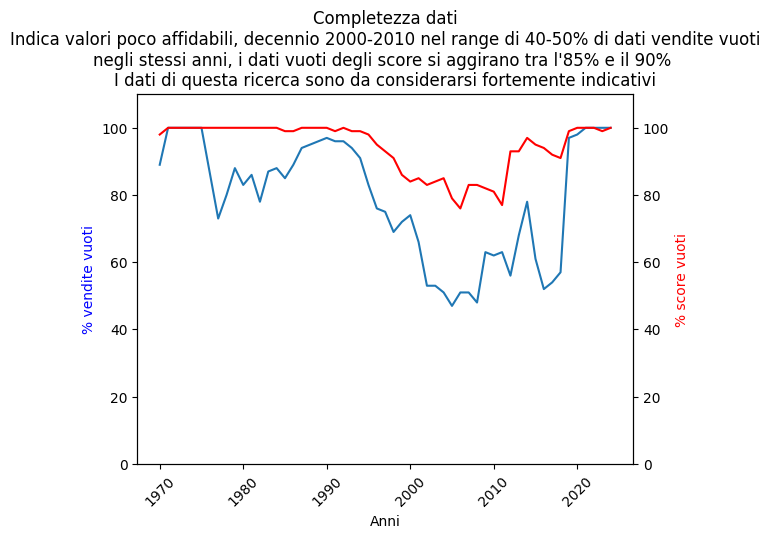

In [14]:
# VENDITE - Global_Sales

# Step 1 - otteniamo la colonna totale titoli sull'anno
df_vendite["Totale_vendite_anno"] = (
    df_vendite.groupby("Year")
    ["Name"]
    .transform("count")
)
# Step 2: filtriamo valori vuoti o uguali a zero
completo = df_vendite[(df_vendite["Global_Sales"] == 0) | (df_vendite["Global_Sales"].isna())].groupby("Year").agg(
    {"Name":"count","Totale_vendite_anno":"mean"}
).reset_index()

# Step 3: creiamo una colonna per indicare la % di titoli senza dati economici sul totale delle vendite dell'anno
completo["perc_differenza_vendite"] = round(completo["Name"]/completo["Totale_vendite_anno"]*100,)

#VOTI - Critic_Score
# Step 1 - filtriamo score vuoti o uguali a zero
df_score = df_vendite[(df_vendite["Critic_Score"] == 0) | (df_vendite["Critic_Score"].isna())].groupby("Year").agg( 
    {"Name":"count","Totale_vendite_anno":"mean"}
).reset_index()

# Step 2: creiamo la % di titoli con score vuoto
df_score["perc_differenza_score"]  =round(df_score["Name"]/df_score["Totale_vendite_anno"]*100)


# GRAFICO
df_score_sales = pd.DataFrame({"Year":df_score.Year, "Empty_Sales_perc":completo.perc_differenza_vendite, "Empty_Score_perc":df_score.perc_differenza_score})

x = df_score_sales.Year
y1 = df_score_sales.Empty_Sales_perc
y2 = df_score_sales.Empty_Score_perc

fig, ax1 = plt.subplots()

ax1.plot(x,y1)
ax1.set_title(f"Completezza dati\nIndica valori poco affidabili, decennio 2000-2010 nel range di 40-50% di dati vendite vuoti"
              f"\nnegli stessi anni, i dati vuoti degli score si aggirano tra l'85% e il 90% \nI dati di questa ricerca sono da considerarsi fortemente indicativi")
     
ax1.set_xlabel("Anni")
ax1.set_ylabel("% vendite vuoti", color = "blue")  
ax1.set_ylim(0,110)
ax1.tick_params(axis="x", labelrotation=45 )# ruota etichette

ax2 = ax1.twinx()  # inizializza il secondo asse
ax2.plot(x,y2, color = "red")
ax2.set_ylabel(r'% score vuoti', color="red")  
ax2.set_ylim(0,110)

plt.gca().xaxis.get_major_formatter().set_useOffset(False)
plt.show()

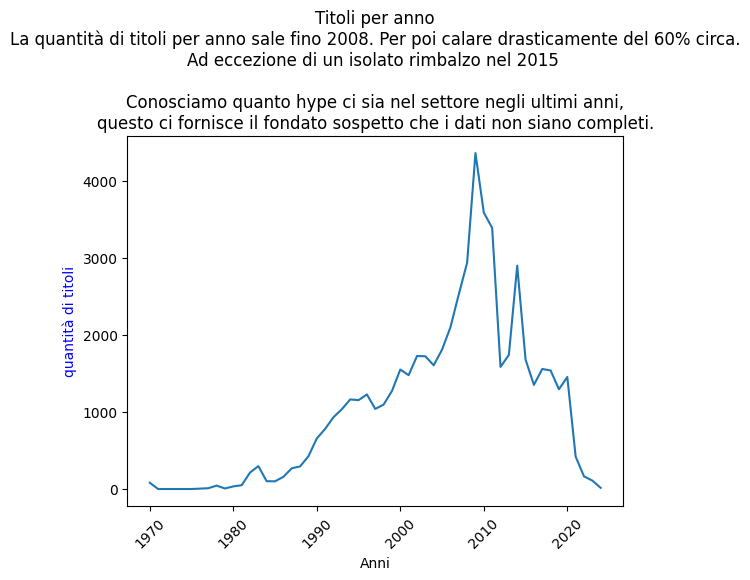

In [15]:
# Quantità titoli per ciascun anno

# GRAFICO
df_quantita_anno = df_vendite.groupby("Year")["Name"].count() 

x = df_quantita_anno.index
y = df_quantita_anno.values

fig, ax1 = plt.subplots()

ax1.plot(x,y)
ax1.set_title(
"Titoli per anno\n"
"La quantità di titoli per anno sale fino 2008. Per poi calare drasticamente del 60% circa.\n"
"Ad eccezione di un isolato rimbalzo nel 2015 \n\n"
"Conosciamo quanto hype ci sia nel settore negli ultimi anni,\n"
"questo ci fornisce il fondato sospetto che i dati non siano completi."
)

ax1.set_xlabel("Anni")
ax1.set_ylabel("quantità di titoli", color = "blue")  
ax1.tick_params(axis="x", labelrotation=45 )# ruota etichette


### 🎮 Quale genere compra di più un gamer?

1. ##### Andamento vendite per anno

    Il grafico delle vendite rispecchia quanto abbiamo visto in precedenza con la quantità dei titoli.
    Infatti dal 2008 si avvia un costante un calo di vendite che non si addice ad un industria che macina sempre più titoli con enorme successo e platee di consumatori mondiali.
    

2. ##### Top 5 generi

    I 5 generi che hanno venduto di più da sempre sono: Action Platform, Role-Playing,Shooter e Sports

    Le vendite dal 2000 al 2018 (dopo non abbiamo dati utili) mostrano il boom del 2006-2010 già visto in precedenza. 
    Nonostante i dati siano probabilmente carenti per i periodi successivi, vediamo che **Role-Playing** ha mantenuto le quote iniziali, mentre Shooter le ha addirittura aumentate



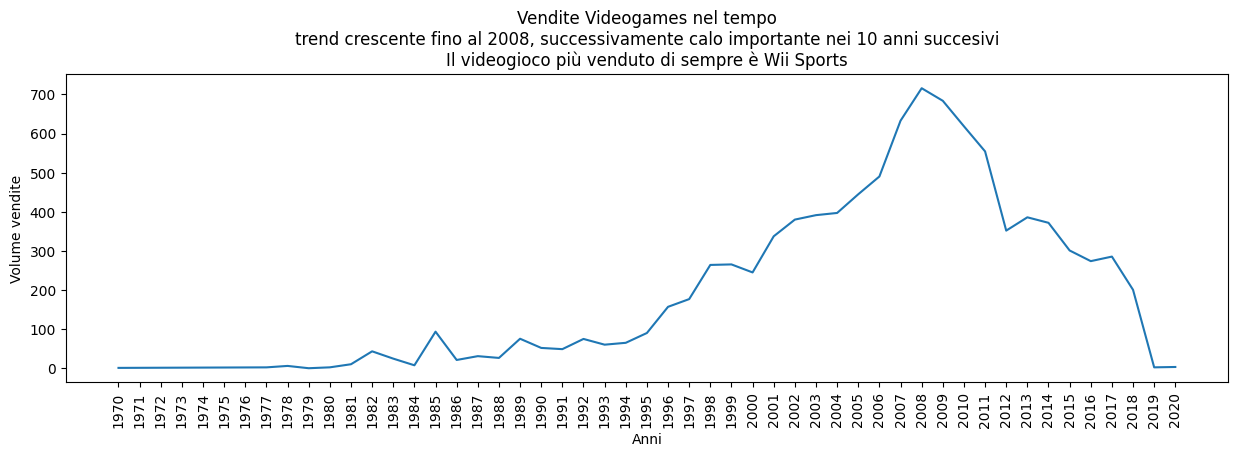

In [16]:
# ==== Andamento vendite annuali ====

# Step 1: filtro vendite diverso da 0 e non nulle
filtrato = df_vendite[(df_vendite["Global_Sales"] != 0) & (df_vendite["Global_Sales"].notna())]

# Step 2: raggruppo per anno,nome e proprietari
giochi_piu_venduti = filtrato.groupby(["Year","Name"])["Global_Sales"].sum().reset_index()

#Step 3: raggruppo per anno creando una partizione e ordino per ranking in base alle vendite totali discendenti
giochi_piu_venduti["rank"] = giochi_piu_venduti.groupby("Year")["Global_Sales"].rank(method="dense",ascending=False)

#Step 4: filtro il rank = 1 per avere i primi posti per ciascun anno
chart_anno = giochi_piu_venduti[giochi_piu_venduti["rank"] == 1].sort_values(by=["Year"], ascending=True)

best_seller_ever = giochi_piu_venduti.sort_values(by="Global_Sales", ascending=False).head(1)["Name"].values[0]

totali_vendite_per_anno = filtrato.groupby("Year")["Global_Sales"].sum().reset_index()

#Step 5: visualizzazione con grafico lineare

plt.figure(figsize=(15,4))

x= totali_vendite_per_anno.Year
y = totali_vendite_per_anno.Global_Sales

plt.plot(x, y)
plt.title(f"Vendite Videogames nel tempo\ntrend crescente fino al 2008, successivamente calo importante nei 10 anni succesivi"
          f"\nIl videogioco più venduto di sempre è {best_seller_ever}")              # SEMPRE
plt.xlabel("Anni")
plt.ylabel("Volume vendite")  
plt.xticks(np.arange(min(x), max(x) + 1, 1), # mostra tutte le etichette 
    rotation=90 # ruota etichette
)     
plt.gca().xaxis.get_major_formatter().set_useOffset(False)
plt.show()


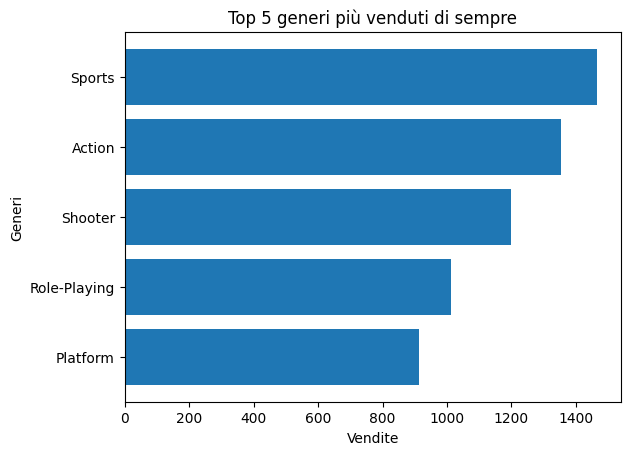

In [17]:
# ==== Top 5 Generi più venduti di sempre ====

# Raggruppiamo per genere
df_generi = df_vendite.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=True).tail(5)

# Visualizzazione in grafico
fig,ax = plt.subplots()

y=df_generi.values
x=df_generi.index

ax.set_title("Top 5 generi più venduti di sempre")
ax.set_xlabel('Vendite')
ax.set_ylabel('Generi')
ax.barh(x,y)
plt.show()

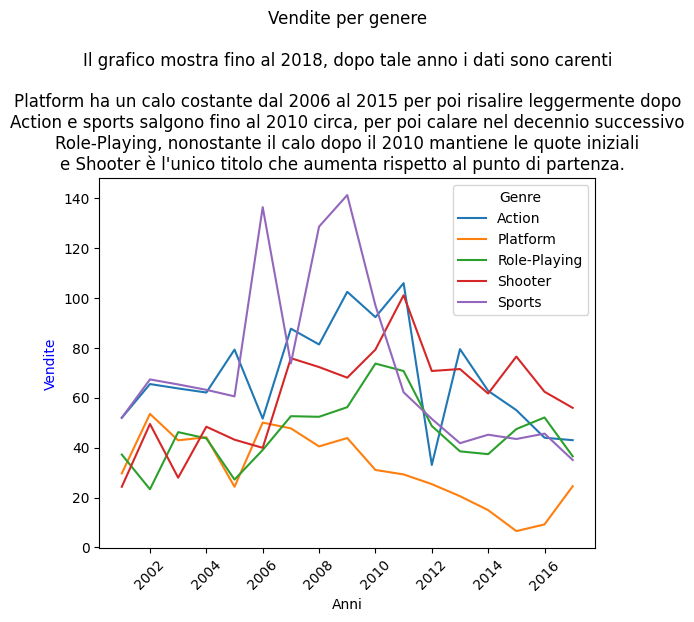

In [18]:
# ==== Vendite 2000-2018 della categoria top 5 ====

# Step 1: produciamo la lista dei top 5 e filtriamo i nostri dati
top5_generi = list(df_generi.index)[::-1]
df_trend_generi = df_vendite.loc[df_vendite["Genre"].isin(top5_generi)]


# Step 2: creiamo una tabella con le vendite di ciascuna categoria suddivisa per anno
df_trend_generi = (
    df_vendite.loc[(df_vendite["Genre"].isin(top5_generi))&(df_vendite["Year"] >2000)&(df_vendite["Year"] < 2018)]
    .pivot_table(
        values="Global_Sales",
        index="Year",
        columns="Genre",
        aggfunc="sum"
    )
    .reset_index()
)

# GRAFICO

fix, ax1 = plt.subplots()

df_trend_generi.plot(x="Year", ax=ax1)
ax1.set_title(
"Vendite per genere\n\n"
"Il grafico mostra fino al 2018, dopo tale anno i dati sono carenti\n\n"
"Platform ha un calo costante dal 2006 al 2015 per poi risalire leggermente dopo\n"
"Action e sports salgono fino al 2010 circa, per poi calare nel decennio successivo\n"
"Role-Playing, nonostante il calo dopo il 2010 mantiene le quote iniziali\n"
"e Shooter è l'unico titolo che aumenta rispetto al punto di partenza.  " 
)
        
ax1.set_xlabel("Anni")
ax1.tick_params(axis="x", labelrotation=45 )# ruota etichette
ax1.set_ylabel(f"Vendite", color = "blue")  

plt.gca().xaxis.get_major_formatter().set_useOffset(False)
plt.show()

### 🖱️ Cosa dicono i dati attuali? 
#### Usiamo il dataset SteamSpy con i dati attuali da Steam

1. ##### Quali sono i 20 giochi più votati su PC?
    Il primo in classifica supera di 4 volte il secondo, ed è uno Shooter. Counter-Strike: Global Offensive è il gioco più votato in assoluto. 
    Seguono titoli di azione-avvenutura didiversa fattura e temi, GTA V e Terraria  al secondo e terzo posto.
    Notiamo come ci siano altri titoli sparatutto, e molti titoli di azione.
    Nella top 20 troviamo solo Black Myth: Wukong come RPG puro.

2. ##### Quali sono le categorie più votate su PC al momento?
    Al contrario di quanto mostrato con il dataset di Kaggle, gli utenti votano tanto e positivamente titoli di azione. Segno che c'è interesse. 
    Gli shooter mantengono una la posizione in vetta.
    Seguono poi giochi strategy, non emersi dal dataset di Kaggle.
    Infine al quarto posto gli RPG mantengono la loro quota confermando l'intuizione che avevamo fatto precedentemente.

##### **Nota** 
I generi riportati in questo dataset sono più dettagliati di Kaggle.
Alcuni titoli sembrano avere diversi generi per la classificazione di Steam. 
Ho scelto di unire i generi per avere una sfumatura più precisa del sapore del gioco.
Per i titoli presenti in entrambi i dataset i generi sono stati uniformati al dataset di Kaggle, per mantenere coerenza
    

In [19]:
# Preparazione del dataset

#raggruppamento dati di interesse - per ottenere tutti i generi in un solo campo "genre"

# Create colonne di somma score positivi e negativi e % di voti positivi
df_steamspy["total_score"] = df_steamspy["positive"] + df_steamspy["negative"]
df_steamspy["positive_perc"] = round(df_steamspy.positive / df_steamspy.total_score *100,2)

df_steamspy_completo["total_score"] = df_steamspy_completo["positive"] + df_steamspy_completo["negative"]
df_steamspy_completo["positive_perc"] = round(df_steamspy_completo.positive / df_steamspy_completo.total_score *100,2)

# Le righe sono tutte uguali, raggruppo per nome sommando solo il genere per avere una risposta completa
df_steamspy_completo = df_steamspy_completo.groupby("name").agg(
    {
        "genre":"sum",
        "developer":"first",
        "publisher":"first",
        "owners":"first",
        "positive":"first",
        "negative":"first",
        "price":"first",
        "ccu":"first",
        "total_score":"first",
        "positive_perc":"first",
     }
).reset_index()

# Unisco dataframe Kaggle con Steam per di mantenere uniformità nei generi ove possibile
df2_merge = df_vendite[["Name","Genre"]].drop_duplicates(subset=["Name"]) 

df_steamspy_completo = pd.merge(
    df_steamspy_completo,
    df2_merge,
    how="left",
    left_on="name",
    right_on="Name",
)
#Sostituiamo i valori incompleti
df_steamspy_completo["genre"] = np.where(
    pd.isna(df_steamspy_completo["Genre"]),
    df_steamspy_completo["genre"],
    df_steamspy_completo["Genre"]
    )
df_steamspy_completo = df_steamspy_completo.drop(["Name","Genre"],axis=1)

#Pulizia dei dati - sostituzione - con spazio e rimozione spazi finali
df_steamspy_completo["genre"] = df_steamspy_completo["genre"].str.strip()
df_steamspy_completo["genre"] = df_steamspy_completo["genre"].str.replace("-"," ")
df_steamspy_completo["genre"] = df_steamspy_completo["genre"].str.replace("Role Playing","RPG")

# Carichiamo i dati in un database sql
conn = sqlite3.connect("videogames_analysis.db")

df_steamspy.to_sql(
    "df_steamspy",
    conn,
    if_exists="replace",
    index=False
)

df_steamspy_completo.to_sql(
    "df_completo",
    conn,
    if_exists="replace",
    index=False
)

cur = conn.cursor()

In [20]:
# ===== Top 20 giochi per score totale, con % di voti positivi > 75% ====
query = """
    select * 
    from 
    (SELECT name, genre, developer, publisher, positive, negative, owners,
    ccu, total_score, positive_perc, 
    rank() over (order by total_score desc) as partition 
    from df_completo 
    where total_score <>0 and positive_perc>75
    order by total_score desc
    limit 20)
    order by partition asc
"""
top_20_most_voted_games_by_genre = pd.read_sql(query ,conn)


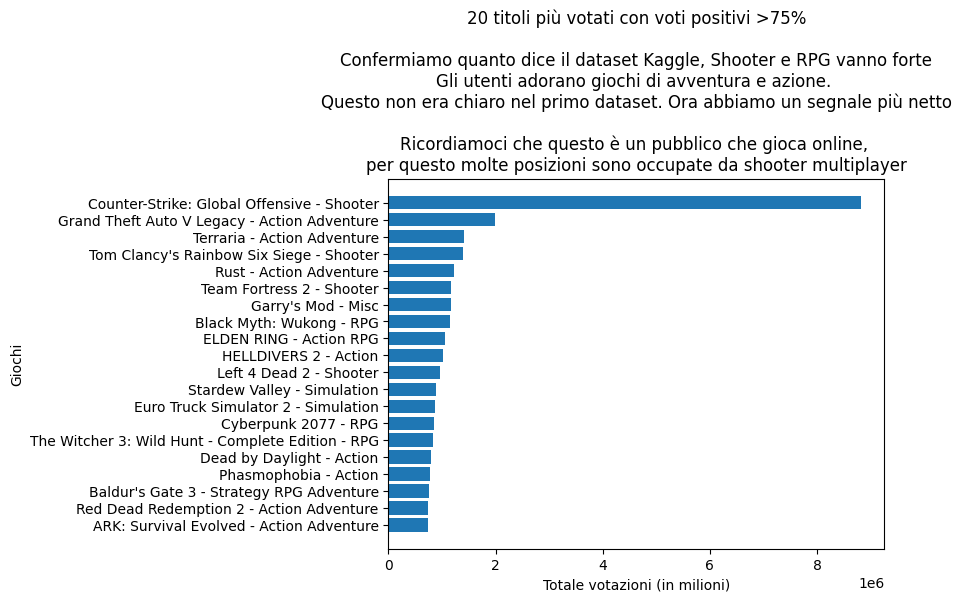

In [21]:
# GRAFICO
df_plot = top_20_most_voted_games_by_genre[::-1]

fig, ax = plt.subplots()

x = df_plot.name +" - " + df_plot.genre 
y= df_plot.total_score

ax.barh(x,y)
ax.set_title("20 titoli più votati con voti positivi >75%" \
"\n\nConfermiamo quanto dice il dataset Kaggle, Shooter e RPG vanno forte" \
"\nGli utenti adorano giochi di avventura e azione. " \
"\nQuesto non era chiaro nel primo dataset. Ora abbiamo un segnale più netto" \
"\n\nRicordiamoci che questo è un pubblico che gioca online, " \
"\nper questo molte posizioni sono occupate da shooter multiplayer")
ax.set_xlabel('Totale votazioni (in milioni)')
ax.set_ylabel('Giochi')
plt.show()

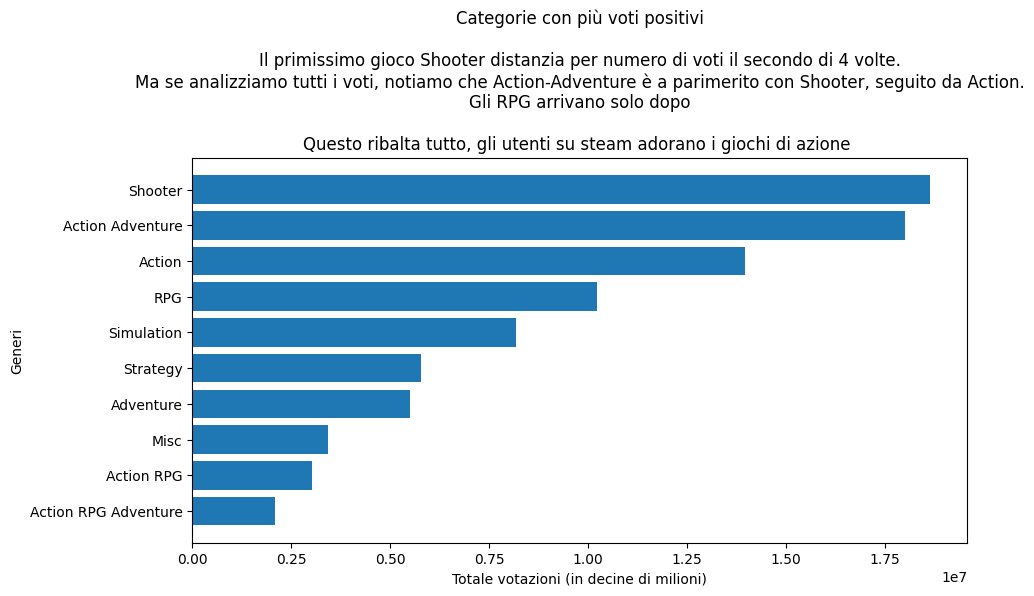

In [ ]:
# ===== Top 10 categorie per score totale, con % di voti positivi > 75% ====

# Step 1: prepariamo la query
query = """
    select genre,SUM(positive) as Total_score, MAX(positive_perc) as positive_perc
    from df_completo
        where positive_perc > 75
    group by genre 
    order by SUM(positive) desc 
    limit 10
"""
# Step 2: trasformiamo in dataframe, e lo invertiamo per il grafico a barre
top_10_categories =  pd.read_sql(query,conn)[::-1]
top_10_categories


# GRAFICO
fig, ax = plt.subplots(figsize=(10,5))

x = top_10_categories.genre
y= top_10_categories.Total_score

ax.barh(x,y)
ax.set_title("Categorie con più voti positivi" \
"\n\nIl primissimo gioco Shooter distanzia per numero di voti il secondo di 4 volte." \
"\nMa se analizziamo tutti i voti, notiamo che Action-Adventure è a parimerito con Shooter, seguito da Action." \
"\nGli RPG arrivano solo dopo" \
"\n\nQuesto ribalta tutto, gli utenti su steam adorano i giochi di azione ")
ax.set_xlabel('Totale votazioni (in decine di milioni)')
ax.set_ylabel('Generi')
ax.ticklabel_format()
plt.show()



### 💻 **Cosa produciamo?**

#### Ci lanciamo su 💣 Action, 🔫 Shooter, 🧙 GDR o ♟️ Strategy ?
#### Ma attenzione...

I dati ci dicono che i gamer adorano i giochi di azione, shooter, strategici e GDR. Ma c'è un rovescio della medaglia che spiego alla fine della presentazione cui stare **molto attenti**‼️. 

Possiamo lanciarci su uno dei generi singolarmente e cercare un modo per disinguerci. Sia esso la trama, la lore o un ambientazione non ancora esplorata in questi generi. 

Oppure possiamo produrre un mix di questi generi, strada azzardata ma affascinante.

Quale strada scegliere, lo rimandiamo alla prossima decisione!

🛑 **Attenzione** al boss finale. Nonostante la coerenza dell'output, i dati mostrati **NON** possono essere considerati affidabili al 100%. 

Le valutazioni vanno validate con altri metodi più diretti, come sondaggi o interviste.    